# MaxEnt species distribution model

Этот блокнот строит модель **MaxEnt** по готовым GeoTIFF-предикторам и CSV с точками присутствия.

## Что делает ноутбук

1. Берёт данные из папки `data_predictors`.
2. Использует только `.tif`-растры-предикторы и `.csv` с точками присутствия.
3. Проверяет, что все растры лежат на одной сетке: одинаковый CRS, размер и transform.
4. Генерирует фоновые точки.
5. Извлекает значения предикторов в точках присутствия и фоновых точках.
6. Обучает модель MaxEnt.
7. Считает AUC на train/test.
8. Считает **пермутационную важность предикторов**.
9. Строит итоговый GeoTIFF-прогноз `maxent_prediction.tif`.

> ASC-файлы в этом ноутбуке не используются.


## 1. Установка библиотек

Для запуска в Google Colab нужна библиотека `elapid`. Остальные библиотеки обычно уже установлены в Colab.

In [1]:
# Установка elapid для MaxEnt
!pip install elapid -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.5/436.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 45.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


## 2. Подключение Google Drive

Если ноутбук запускается не в Colab, эту ячейку можно пропустить.

In [2]:
# Подключение Google Drive в Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Настройки проекта

Измени `DATA_DIR`, если папка с данными лежит в другом месте. В этой папке должны быть:

- `.tif` — растры-предикторы;
- `.csv` — точки присутствия вида `lon/lat`, `longitude/latitude` или `x/y`.


In [3]:
# =========================
# НАСТРОЙКИ
# =========================

# Основной путь к папке с данными.
# Если путь не найден, код ниже дополнительно проверит альтернативные варианты.
DATA_DIR = "/content/drive/MyDrive/Seminar_11/data_predictors"

# Если CSV с точками присутствия называется конкретно, можно указать имя файла.
# Если оставить None, будет взят первый CSV-файл в папке DATA_DIR.
PRESENCE_CSV_NAME = None
# Пример:
# PRESENCE_CSV_NAME = "d1000_441.csv"

# CRS координат в CSV.
# None означает: считать, что точки уже в CRS растров.
# Если точки в долготе/широте, а растры в другой проекции, поставь POINTS_CRS = "EPSG:4326".
POINTS_CRS = None

# Количество фоновых точек для MaxEnt.
BACKGROUND_COUNT = 10_000

# Параметры MaxEnt.
MAXENT_TRANSFORM = "cloglog"
BETA_MULTIPLIER = 1.0

# Разделение данных для оценки качества.
TEST_SIZE = 0.25
RANDOM_SEED = 42

# Пермутационная важность.
PERMUTATION_REPEATS = 10

# Размер блока при записи прогноза.
# Если Colab падает по памяти, уменьши до 128 или 64.
BLOCK_SIZE = 256

# Имена выходных файлов.
OUTPUT_RASTER_NAME = "maxent_prediction.tif"
MODEL_NAME = "maxent_model.ela"
PERMUTATION_IMPORTANCE_NAME = "permutation_importance.csv"

## 4. Импорт библиотек и вспомогательные функции

In [4]:
# =========================
# ИМПОРТЫ
# =========================

import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import elapid as ela
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.model_selection import train_test_split
from rasterio.windows import Window

warnings.filterwarnings("ignore", category=UserWarning)


def resolve_data_dir(data_dir):
    """Возвращает существующую папку с данными."""
    candidates = [
        data_dir,
        "/content/drive/MyDrive/Seminar_11/data/data_predictors",
        "/content/drive/MyDrive/Seminar_11/data_predictors",
    ]

    for candidate in candidates:
        if candidate and os.path.isdir(candidate):
            return candidate

    raise FileNotFoundError(
        "Не найдена папка data_predictors. Проверь DATA_DIR в настройках."
    )


def find_coordinate_columns(df):
    """Автоматически ищет колонки X/Y в CSV с точками присутствия."""
    possible_x_cols = [
        "x", "X",
        "lon", "Lon", "LON",
        "lng", "Lng", "LNG",
        "long", "Long", "LONG",
        "longitude", "Longitude", "LONGITUDE",
        "decimalLongitude", "DecimalLongitude",
    ]

    possible_y_cols = [
        "y", "Y",
        "lat", "Lat", "LAT",
        "latitude", "Latitude", "LATITUDE",
        "decimalLatitude", "DecimalLatitude",
    ]

    x_col = next((col for col in possible_x_cols if col in df.columns), None)
    y_col = next((col for col in possible_y_cols if col in df.columns), None)

    if x_col is None or y_col is None:
        raise ValueError(
            "Не найдены колонки координат. "
            "Переименуй их в lon/lat, longitude/latitude или x/y."
        )

    return x_col, y_col


def validate_rasters(raster_paths):
    """Проверяет, что все растры имеют одинаковую сетку."""
    if len(raster_paths) == 0:
        raise FileNotFoundError("В папке не найдено входных .tif-растров.")

    with rasterio.open(raster_paths[0]) as src0:
        ref_shape = src0.shape
        ref_crs = src0.crs
        ref_transform = src0.transform

    if ref_crs is None:
        raise ValueError(
            "У первого GeoTIFF нет CRS. Нужно записать CRS в растры перед запуском модели."
        )

    for raster_path in raster_paths:
        with rasterio.open(raster_path) as src:
            if src.shape != ref_shape:
                raise ValueError(
                    f"Растр {os.path.basename(raster_path)} имеет размер {src.shape}, "
                    f"а должен быть {ref_shape}. Нужно выровнять растры."
                )

            if src.crs != ref_crs:
                raise ValueError(
                    f"CRS растра {os.path.basename(raster_path)} отличается от первого растра."
                )

            if src.transform != ref_transform:
                raise ValueError(
                    f"Transform растра {os.path.basename(raster_path)} отличается от первого растра. "
                    "Все предикторы должны быть на одной сетке."
                )

    return ref_shape, ref_crs, ref_transform

## 5. Поиск входных данных

Из папки берутся только `.tif`-файлы. Выходные файлы предыдущих запусков исключаются, чтобы они случайно не попали в список предикторов.

In [6]:
# =========================
# ПОИСК ДАННЫХ
# =========================

data_dir = resolve_data_dir(DATA_DIR)
print("Папка с данными:", data_dir)

# Исключаем выходные файлы предыдущих запусков.
excluded_tif_names = {
    OUTPUT_RASTER_NAME,
    "maxent_prediction_blocks.tif",
    "prediction.tif",
}

all_tifs = sorted(glob.glob(os.path.join(data_dir, "*.tif")))
raster_paths_for_maxent = [
    path for path in all_tifs
    if os.path.basename(path) not in excluded_tif_names
]

if PRESENCE_CSV_NAME is None:
    csv_files = sorted(glob.glob(os.path.join(data_dir, "*.csv")))
    if len(csv_files) == 0:
        raise FileNotFoundError("В папке data_predictors не найден CSV с точками присутствия.")
    presence_csv_path = csv_files[0]
else:
    presence_csv_path = os.path.join(data_dir, PRESENCE_CSV_NAME)
    if not os.path.exists(presence_csv_path):
        raise FileNotFoundError(f"CSV-файл не найден: {presence_csv_path}")

print("Найдено GeoTIFF-предикторов:", len(raster_paths_for_maxent))
for path in raster_paths_for_maxent:
    print(" -", os.path.basename(path))

print("CSV с точками присутствия:", os.path.basename(presence_csv_path))

Папка с данными: /content/drive/MyDrive/Seminar_11/data/data_predictors
Найдено GeoTIFF-предикторов: 7
 - dist_to_road.tif
 - dist_to_vill.tif
 - dist_to_water.tif
 - lands.tif
 - prrr.tif
 - soil.tif
 - twi.tif
CSV с точками присутствия: d1000_441.csv


## 6. Загрузка точек присутствия и проверка растров

Важно: точки присутствия и растры должны быть в согласованных координатах. Если CSV содержит lon/lat, а растры в другой проекции, укажи `POINTS_CRS = "EPSG:4326"` в настройках.

In [9]:
# =========================
# ТОЧКИ ПРИСУТСТВИЯ И РАСТРЫ
# =========================

# Проверяем растры.
raster_shape, raster_crs, raster_transform = validate_rasters(raster_paths_for_maxent)

print("CRS растров:", raster_crs)
print("Размер растров:", raster_shape)
print("Все растры имеют одинаковый CRS, размер и transform.")

# Загружаем CSV с точками присутствия.
presence_df = pd.read_csv(presence_csv_path)
print("Первые строки CSV:")
print(presence_df.head())

x_col, y_col = find_coordinate_columns(presence_df)
print("Колонка X:", x_col)
print("Колонка Y:", y_col)

# Оставляем только строки с корректными координатами.
presence_df = presence_df.copy()
presence_df[x_col] = pd.to_numeric(presence_df[x_col], errors="coerce")
presence_df[y_col] = pd.to_numeric(presence_df[y_col], errors="coerce")
presence_df = presence_df.dropna(subset=[x_col, y_col])

if len(presence_df) == 0:
    raise ValueError("После удаления пустых координат в CSV не осталось точек.")

# CRS точек: либо задан вручную, либо считается таким же, как у растров.
points_crs = POINTS_CRS if POINTS_CRS is not None else raster_crs

presence_gdf = gpd.GeoDataFrame(
    presence_df,
    geometry=gpd.points_from_xy(presence_df[x_col], presence_df[y_col]),
    crs=points_crs,
)

if presence_gdf.crs != raster_crs:
    presence_gdf = presence_gdf.to_crs(raster_crs)

print("Точек присутствия:", len(presence_gdf))

CRS растров: EPSG:4326
Размер растров: (4801, 7958)
Все растры имеют одинаковый CRS, размер и transform.
Первые строки CSV:
                species        lon        lat
0  Heracleum sosnowskyi  36.348024  55.818800
1  Heracleum sosnowskyi  36.269125  55.778401
2  Heracleum sosnowskyi  36.034920  56.058520
3  Heracleum sosnowskyi  35.761796  56.060979
4  Heracleum sosnowskyi  36.180913  55.779850
Колонка X: lon
Колонка Y: lat
Точек присутствия: 441


## 7. Фоновые точки и извлечение значений предикторов

MaxEnt обучается на точках присутствия и фоновых точках. Для всех этих точек извлекаются значения каждого растрового предиктора.

In [11]:
# =========================
# ФОНОВЫЕ ТОЧКИ И ANNOTATE
# =========================

# Генерируем фоновые точки по первому растровому предиктору.
background_gdf = ela.sample_raster(
    raster_paths_for_maxent[0],
    count=BACKGROUND_COUNT,
)

if background_gdf.crs is None:
    background_gdf = background_gdf.set_crs(raster_crs, allow_override=True)

if background_gdf.crs != raster_crs:
    background_gdf = background_gdf.to_crs(raster_crs)

print("Фоновых точек:", len(background_gdf))

# Объединяем presence/background и добавляем class:
# class = 1 для точек присутствия, class = 0 для фоновых точек.
merged_gdf = ela.stack_geodataframes(
    presence_gdf,
    background_gdf,
    add_class_label=True,
)

# Извлекаем значения растров в точках.
annotated = ela.annotate(
    merged_gdf,
    raster_paths_for_maxent,
    drop_na=True,
    quiet=True,
)

if len(annotated) == 0:
    raise ValueError(
        "После annotate получилось 0 строк. "
        "Скорее всего, точки не попадают на растры или в предикторах слишком много NoData."
    )

print("Строк после annotate:", len(annotated))
print("Первые строки таблицы для обучения:")
print(annotated.head())

Фоновых точек: 10000
Строк после annotate: 10435
Первые строки таблицы для обучения:
                    geometry  class           b1            b2           b3  \
0   POINT (36.34802 55.8188)      1  3672.396973   2173.500000   840.000000   
1   POINT (36.26913 55.7784)      1   134.164093   1878.776001  1830.983032   
2  POINT (36.03492 56.05852)      1   152.970596  12902.719727  9918.210938   
3   POINT (35.7618 56.06098)      1   818.840576   2713.301025  3380.960938   
4  POINT (36.18091 55.77985)      1  1230.365967   7788.742188  2190.000000   

    b4    b5     b6         b7  
0  5.0  86.0   38.0 -10.143450  
1  4.0  85.0  307.0  -8.798176  
2  5.0  85.0   39.0 -10.096550  
3  4.0  84.0   38.0  -6.942273  
4  4.0  84.0   39.0  -8.705571  


## 8. Обучение и оценка MaxEnt

Модель обучается на части данных, а качество оценивается по AUC на train и test. Это удобнее для отчёта, чем оценка только на обучающей выборке.

In [13]:
# =========================
# ОБУЧЕНИЕ MAXENT
# =========================

X = annotated.drop(columns=["geometry", "class"])
y = annotated["class"].astype(int)

print("Предикторы модели:")
print(list(X.columns))

# Stratify используется, чтобы сохранить долю presence/background в train и test.
stratify = y if y.nunique() == 2 and y.value_counts().min() > 1 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=stratify,
)

model = ela.MaxentModel(
    transform=MAXENT_TRANSFORM,
    beta_multiplier=BETA_MULTIPLIER,
)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_auc = metrics.roc_auc_score(y_train, train_pred)
test_auc = metrics.roc_auc_score(y_test, test_pred)

print(f"Train AUC: {train_auc:.3f}")
print(f"Test AUC:  {test_auc:.3f}")

model_path = os.path.join(data_dir, MODEL_NAME)
ela.save_object(model, model_path)
print("Модель сохранена:", model_path)

Предикторы модели:
['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7']
Train AUC: 0.851
Test AUC:  0.826
Модель сохранена: /content/drive/MyDrive/Seminar_11/data/data_predictors/maxent_model.ela


## 9. Пермутационная важность предикторов

Пермутационная важность показывает, насколько падает AUC, если случайно перемешать значения одного предиктора. Чем больше падение AUC, тем важнее предиктор для модели.

Результат сохраняется в `permutation_importance.csv`.

Пермутационная важность сохранена: /content/drive/MyDrive/Seminar_11/data/data_predictors/permutation_importance.csv
  predictor  baseline_auc  mean_permuted_auc  std_permuted_auc  auc_drop
0        b4      0.825523           0.619224          0.014964  0.206299
1        b1      0.825523           0.783046          0.008032  0.042477
2        b5      0.825523           0.802396          0.004112  0.023127
3        b6      0.825523           0.811634          0.007775  0.013889
4        b2      0.825523           0.820878          0.003491  0.004645
5        b7      0.825523           0.821904          0.005825  0.003619
6        b3      0.825523           0.821959          0.002979  0.003564


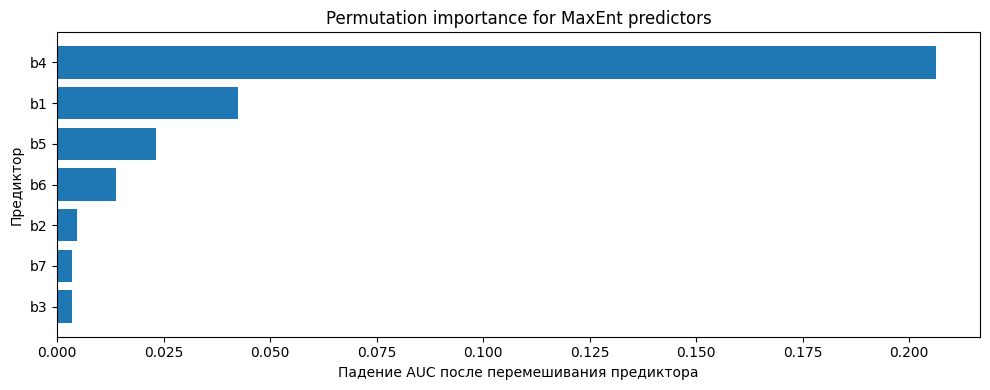

In [14]:
# =========================
# ПЕРМУТАЦИОННАЯ ВАЖНОСТЬ
# =========================

rng = np.random.default_rng(RANDOM_SEED)

# Важность считаем на test-выборке, чтобы оценка была честнее.
importance_X = X_test.copy()
importance_y = y_test.copy()
baseline_auc = metrics.roc_auc_score(importance_y, model.predict(importance_X))

importance_rows = []

for feature in importance_X.columns:
    permuted_aucs = []

    for _ in range(PERMUTATION_REPEATS):
        X_permuted = importance_X.copy()
        X_permuted[feature] = rng.permutation(X_permuted[feature].to_numpy())

        permuted_pred = model.predict(X_permuted)
        permuted_auc = metrics.roc_auc_score(importance_y, permuted_pred)
        permuted_aucs.append(permuted_auc)

    mean_permuted_auc = float(np.mean(permuted_aucs))
    std_permuted_auc = float(np.std(permuted_aucs))
    auc_drop = float(baseline_auc - mean_permuted_auc)

    importance_rows.append({
        "predictor": feature,
        "baseline_auc": baseline_auc,
        "mean_permuted_auc": mean_permuted_auc,
        "std_permuted_auc": std_permuted_auc,
        "auc_drop": auc_drop,
    })

permutation_importance = (
    pd.DataFrame(importance_rows)
    .sort_values("auc_drop", ascending=False)
    .reset_index(drop=True)
)

importance_path = os.path.join(data_dir, PERMUTATION_IMPORTANCE_NAME)
permutation_importance.to_csv(importance_path, index=False)

print("Пермутационная важность сохранена:", importance_path)
print(permutation_importance)

# Визуализация важности.
plt.figure(figsize=(10, max(4, 0.45 * len(permutation_importance))))
plt.barh(
    permutation_importance["predictor"][::-1],
    permutation_importance["auc_drop"][::-1],
)
plt.xlabel("Падение AUC после перемешивания предиктора")
plt.ylabel("Предиктор")
plt.title("Permutation importance for MaxEnt predictors")
plt.tight_layout()
plt.show()

## 10. Прогноз по растрам

Прогноз считается блоками, чтобы не загружать все растры целиком в память. Это важно для Colab и больших GeoTIFF-файлов.

In [15]:
# =========================
# ПРОГНОЗ ПО РАСТРАМ БЛОКАМИ
# =========================

output_raster = os.path.join(data_dir, OUTPUT_RASTER_NAME)

with rasterio.open(raster_paths_for_maxent[0]) as src0:
    profile = src0.profile.copy()
    height = src0.height
    width = src0.width

profile.update(
    driver="GTiff",
    dtype="float32",
    count=1,
    nodata=-9999.0,
    compress="lzw",
)

with rasterio.open(output_raster, "w", **profile) as dst:
    total_blocks = int(np.ceil(height / BLOCK_SIZE) * np.ceil(width / BLOCK_SIZE))
    processed_blocks = 0

    for row_start in range(0, height, BLOCK_SIZE):
        for col_start in range(0, width, BLOCK_SIZE):
            win_height = min(BLOCK_SIZE, height - row_start)
            win_width = min(BLOCK_SIZE, width - col_start)

            window = Window(
                col_start,
                row_start,
                win_width,
                win_height,
            )

            block_arrays = []

            for raster_path in raster_paths_for_maxent:
                with rasterio.open(raster_path) as src:
                    arr = src.read(1, window=window).astype("float32")

                    nodata = src.nodata
                    if nodata is not None:
                        arr[arr == nodata] = np.nan

                    block_arrays.append(arr)

            block_stack = np.stack(block_arrays, axis=-1)
            valid_mask = np.all(np.isfinite(block_stack), axis=-1)

            prediction_block = np.full(
                (win_height, win_width),
                -9999.0,
                dtype="float32",
            )

            if valid_mask.sum() > 0:
                flat_values = block_stack[valid_mask]
                predict_df = pd.DataFrame(flat_values, columns=X.columns)
                prediction_block[valid_mask] = model.predict(predict_df).astype("float32")

            dst.write(prediction_block, 1, window=window)

            processed_blocks += 1
            if processed_blocks % 25 == 0 or processed_blocks == total_blocks:
                print(f"Обработано блоков: {processed_blocks}/{total_blocks}")

print("Карта пригодности сохранена:", output_raster)

Обработано блоков: 25/608
Обработано блоков: 50/608
Обработано блоков: 75/608
Обработано блоков: 100/608
Обработано блоков: 125/608
Обработано блоков: 150/608
Обработано блоков: 175/608
Обработано блоков: 200/608
Обработано блоков: 225/608
Обработано блоков: 250/608
Обработано блоков: 275/608
Обработано блоков: 300/608
Обработано блоков: 325/608
Обработано блоков: 350/608
Обработано блоков: 375/608
Обработано блоков: 400/608
Обработано блоков: 425/608
Обработано блоков: 450/608
Обработано блоков: 475/608
Обработано блоков: 500/608
Обработано блоков: 525/608
Обработано блоков: 550/608
Обработано блоков: 575/608
Обработано блоков: 600/608
Обработано блоков: 608/608
Карта пригодности сохранена: /content/drive/MyDrive/Seminar_11/data/data_predictors/maxent_prediction.tif


## 11. Визуализация результата

На карте показана предсказанная пригодность местообитаний. Чем выше значение, тем выше пригодность по модели MaxEnt.

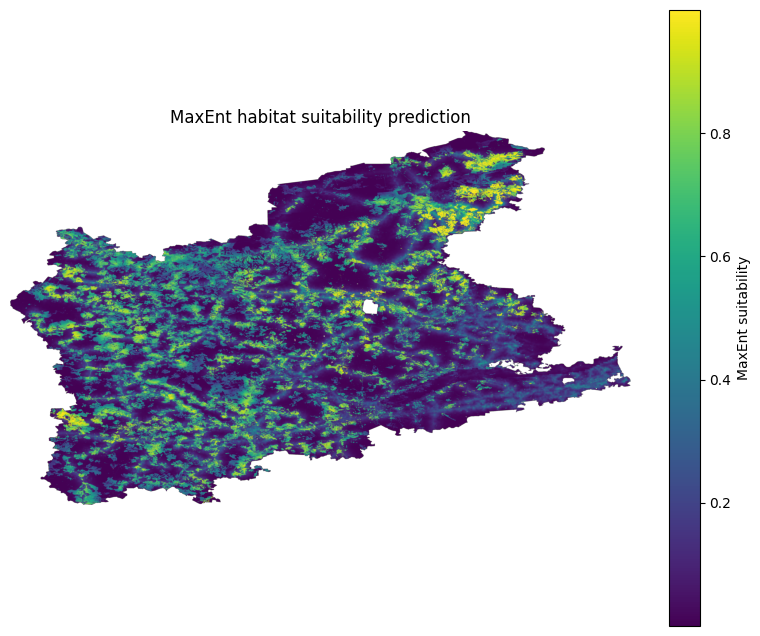

In [16]:
# =========================
# ВИЗУАЛИЗАЦИЯ ПРОГНОЗА
# =========================

with rasterio.open(output_raster) as src:
    prediction = src.read(1).astype("float32")
    nodata = src.nodata
    if nodata is not None:
        prediction[prediction == nodata] = np.nan

plt.figure(figsize=(10, 8))
plt.imshow(prediction)
plt.colorbar(label="MaxEnt suitability")
plt.title("MaxEnt habitat suitability prediction")
plt.axis("off")
plt.show()

## 12. Итоговые файлы

После успешного запуска в папке `data_predictors` появятся:

- `maxent_model.ela` — сохранённая модель MaxEnt;
- `maxent_prediction.tif` — итоговая карта пригодности;
- `permutation_importance.csv` — таблица пермутационной важности предикторов.


In [17]:
print("Готово.")
print("Модель:", os.path.join(data_dir, MODEL_NAME))
print("Прогноз:", os.path.join(data_dir, OUTPUT_RASTER_NAME))
print("Пермутационная важность:", os.path.join(data_dir, PERMUTATION_IMPORTANCE_NAME))

Готово.
Модель: /content/drive/MyDrive/Seminar_11/data/data_predictors/maxent_model.ela
Прогноз: /content/drive/MyDrive/Seminar_11/data/data_predictors/maxent_prediction.tif
Пермутационная важность: /content/drive/MyDrive/Seminar_11/data/data_predictors/permutation_importance.csv
